# Retrieval-Augmented Generation for Medical Q&A (MedQuAD)
### Journal Club 2026: Section 3, Grounding Language Models in Retrieved Knowledge

This interactive notebook implements a simple **Retrieval-Augmented Generation (RAG)** system,
following the ideas in Lewis et al., *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks* (NeurIPS 2020), https://arxiv.org/abs/2005.11401.

RAG combines two kinds of memory:
- **Parametric memory** — a pretrained sequence-to-sequence generator (the LLM weights).
- **Non-parametric memory** — a dense vector index over an external knowledge base that is *retrieved* at inference time.

Instead of Wikipedia, our knowledge base is **MedQuAD**, a collection of medical question-answer pairs from 12 NIH websites. Given a user question, we retrieve the most relevant medical passages and condition the generator on them to produce a grounded answer.

By the end of this notebook you will:
1. Prepare the Kaggle MedQuAD dataset
2. Build a retrieval knowledge base of medical passages
3. Encode passages with a dense sentence-transformer retriever (a DPR-style encoder) and index them with FAISS
4. Load a Flan-T5 generator (the parametric memory)
5. Assemble the retrieve-then-generate RAG pipeline
6. Compare RAG answers against a closed-book (no-retrieval) baseline
7. Visualize the retrieval embedding space

This notebook is intended for education and method exploration, **not clinical decision-making**.


---
## Section 1. Install Dependencies

In [1]:
# Run this cell only if the packages are missing in your environment.
# It is safe to leave RUN_INSTALLS = False when running in an already prepared kernel.
RUN_INSTALLS = True

if RUN_INSTALLS:
    import subprocess
    import sys

    packages = [
        "kaggle",
        "sentence-transformers",
        "faiss-cpu",
        "transformers",
        "accelerate",
        "pandas",
        "scikit-learn",
        "matplotlib",
        "seaborn",
        "umap-learn",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])
else:
    print("Skipping installation. Set RUN_INSTALLS = True if imports fail.")


---
## Section 2. Kaggle Authentication

If the dataset is already downloaded, skip this section.

For Kaggle downloads, we use the new method using API keys, not the old token in a json file


In [2]:
from google.colab import files

uploaded = files.upload()
print('Uploaded files:', list(uploaded.keys()))


import os
import shutil

os.makedirs('/root/.kaggle', exist_ok=True)

if os.path.exists('/content/kaggle.json'):
    shutil.copy('/content/kaggle.json', '/root/.kaggle/kaggle.json')
elif os.path.exists('/content/kaggle_API.txt'):
    shutil.copy('/content/kaggle_API.txt', '/root/.kaggle/access_token')
else:
    raise FileNotFoundError(
        'Upload kaggle.json or kaggle_API.txt first.'
    )

# os.chmod('/root/.kaggle/kaggle.json', 0o600)
# print('Kaggle token placed at /root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/access_token', 0o600)


Saving kaggle_API.txt to kaggle_API.txt
Uploaded files: ['kaggle_API.txt']


---
## Section 3. Download the MedQuAD Dataset from Kaggle

We use the **MedQuAD (Medical Question-Answer)** dataset, originally built by Ben Abacha & Demner-Fushman
from 12 NIH websites (cancer.gov, MedlinePlus, GARD, niddk.nih.gov, and others). The Kaggle CSV version
provides the columns we need: `question`, `answer`, `source`, and `focus_area`.

Kaggle dataset identifier: `pythonafroz/medquad-medical-question-answer-for-ai-research`

Dataset page: https://www.kaggle.com/datasets/pythonafroz/medquad-medical-question-answer-for-ai-research

> **Expected download size:** ~15 MB — much smaller than an imaging dataset, so this is quick.

In [3]:
! kaggle datasets list -s medquad | head

ref                                                          title                                                size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  --------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
gpreda/medquad                                               MedQuAD                                           5188686  2024-07-01 11:22:48.920000            988          6                1  
jpmiller/layoutlm                                            Healthcare NLP: LLMs, Transformers, Datasets  30098674956  2024-02-16 23:53:09.537000          17042        233        0.9411765  
pythonafroz/medquad-medical-question-answer-for-ai-research  MedQuAD: Medical Question-Answer Dataset          5188686  2024-09-07 11:31:40.877000           5228         14       0.64705884  
thedevastator/comprehensive-medical-q-a-

In [4]:
!kaggle datasets download -d pythonafroz/medquad-medical-question-answer-for-ai-research

Dataset URL: https://www.kaggle.com/datasets/pythonafroz/medquad-medical-question-answer-for-ai-research
License(s): CC-BY-SA-4.0
100% 4.95M/4.95M [00:01<00:00, 3.80MB/s]



---
## Section 4. Explore the Dataset

Let us unzip the archive, load the CSV, and inspect the medical question-answer pairs.

In [5]:
# Unzip the dataset
from pathlib import Path
import zipfile

ZIP_PATH = Path("/content/medquad-medical-question-answer-for-ai-research.zip")
EXTRACT_DIR = Path("/content/medquad")

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Zip file not found: {ZIP_PATH}")

with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(EXTRACT_DIR)

# Locate the CSV file inside the extracted folder
csv_files = list(EXTRACT_DIR.rglob("*.csv"))
print("CSV files found:", [p.name for p in csv_files])
CSV_PATH = csv_files[0]
print(f"Using: {CSV_PATH}")


CSV files found: ['medquad.csv']
Using: /content/medquad/medquad.csv


In [6]:
import pandas as pd

df = pd.read_csv(CSV_PATH)
print(f"Raw rows: {len(df):,}")
print("Columns:", list(df.columns))

# Normalise expected column names (the Kaggle CSV uses these).
df = df.rename(columns={c: c.strip().lower() for c in df.columns})

# Keep only rows with a real question and answer.
df = df.dropna(subset=["question", "answer"])
df = df[df["answer"].str.strip().str.len() > 20].reset_index(drop=True)

print(f"Clean rows: {len(df):,}")
if "focus_area" in df.columns:
    print(f"Distinct focus areas: {df['focus_area'].nunique():,}")
df.head(3)


Raw rows: 16,412
Columns: ['question', 'answer', 'source', 'focus_area']
Clean rows: 16,406
Distinct focus areas: 5,125


,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma


In [7]:
# Peek at one full question-answer pair
row = df.iloc[0]
print("QUESTION:", row["question"])
print()
print("ANSWER  :", row["answer"][:600], "...")
if "focus_area" in df.columns:
    print()
    print("FOCUS AREA:", row.get("focus_area"))
    print("SOURCE    :", row.get("source"))


QUESTION: What is (are) Glaucoma ?

ANSWER  : Glaucoma is a group of diseases that can damage the eye's optic nerve and result in vision loss and blindness. While glaucoma can strike anyone, the risk is much greater for people over 60. How Glaucoma Develops  There are several different types of glaucoma. Most of these involve the drainage system within the eye. At the front of the eye there is a small space called the anterior chamber. A clear fluid flows through this chamber and bathes and nourishes the nearby tissues. (Watch the video to learn more about glaucoma. To enlarge the video, click the brackets in the lower right-hand corner.  ...

FOCUS AREA: Glaucoma
SOURCE    : NIHSeniorHealth


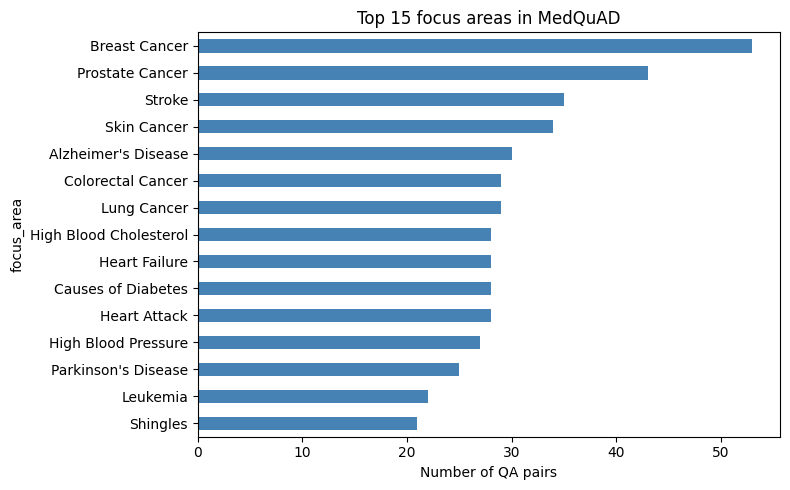

In [8]:
# Distribution of the most common focus areas
import matplotlib.pyplot as plt

if "focus_area" in df.columns:
    top = df["focus_area"].value_counts().head(15)
    plt.figure(figsize=(8, 5))
    top[::-1].plot(kind="barh", color="steelblue")
    plt.title("Top 15 focus areas in MedQuAD")
    plt.xlabel("Number of QA pairs")
    plt.tight_layout()
    plt.show()
else:
    print("No focus_area column available to plot.")


---
## Section 5. Build the Knowledge Base (Non-Parametric Memory)

In the RAG paper, the non-parametric memory is a dense vector index over a large document collection
(Wikipedia passages). Here, **each MedQuAD answer becomes a retrievable passage**. We keep the
originating question and focus area as metadata so we can show provenance for every retrieved passage.

To keep the demo fast, we subsample up to `MAX_DOCS` passages. Increase it for a fuller knowledge base.

In [9]:
MAX_DOCS = 3000
SEED = 42

kb = df.copy()
if len(kb) > MAX_DOCS:
    kb = kb.sample(n=MAX_DOCS, random_state=SEED).reset_index(drop=True)

# Each document is the answer text; we also keep a short "title" for display.
documents = kb["answer"].astype(str).tolist()
doc_titles = kb["question"].astype(str).tolist()
doc_focus = kb["focus_area"].astype(str).tolist() if "focus_area" in kb.columns else [""] * len(kb)

print(f"Knowledge base size: {len(documents):,} passages")
print("Example passage title:", doc_titles[0])
print("Example passage text :", documents[0][:200], "...")


Knowledge base size: 3,000 passages
Example passage title: What is (are) Juvenile Huntington disease ?
Example passage text : Juvenile Huntington disease (HD) is a less common, early-onset form of Huntington disease that begins in childhood or adolescence. It is also a progressive disorder that causes the breakdown of brain  ...


---
## Section 6. Build the Dense Retriever

RAG uses a **Dense Passage Retriever (DPR)**: a bi-encoder that maps queries and documents into the same
vector space, so relevance becomes nearest-neighbour search. We use a compact sentence-transformer
(`all-MiniLM-L6-v2`) as our document/query encoder and index the passage vectors with **FAISS**.

| Component | Choice | Role |
|---|---|---|
| Query / passage encoder | `all-MiniLM-L6-v2` (384-d) | DPR-style dense retriever |
| Vector index | FAISS `IndexFlatIP` (cosine) | Non-parametric memory |

We L2-normalise the embeddings so that inner product equals cosine similarity.

In [10]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

RETRIEVER_NAME = "sentence-transformers/all-MiniLM-L6-v2"
retriever = SentenceTransformer(RETRIEVER_NAME)

# Encode all knowledge-base passages (this is the one-time indexing cost).
doc_embeddings = retriever.encode(
    documents,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
).astype("float32")

dim = doc_embeddings.shape[1]
index = faiss.IndexFlatIP(dim)   # inner product on normalized vectors == cosine similarity
index.add(doc_embeddings)

print(f"Indexed {index.ntotal:,} passages of dimension {dim}.")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Indexed 3,000 passages of dimension 384.


In [11]:
def retrieve(query, k=4):
    """Return the top-k passages for a query as a list of dicts."""
    q_emb = retriever.encode(
        [query], convert_to_numpy=True, normalize_embeddings=True
    ).astype("float32")
    scores, idxs = index.search(q_emb, k)
    results = []
    for score, i in zip(scores[0], idxs[0]):
        results.append({
            "score": float(score),
            "title": doc_titles[i],
            "focus": doc_focus[i],
            "text": documents[i],
        })
    return results


# Quick sanity check
for r in retrieve("What are the symptoms of glaucoma?", k=3):
    print(f"[{r['score']:.3f}] ({r['focus']}) {r['title']}")
    print("   ", r["text"][:150], "...")
    print()


[0.601] (Glaucoma) What is (are) Glaucoma ?
    Glaucoma is a group of diseases that can damage the eye's optic nerve and result in vision loss and blindness. While glaucoma can strike anyone, the r ...

[0.512] (Cogan-Reese syndrome) What is (are) Cogan-Reese syndrome ?
    Cogan-Reese syndrome is one type of Iridocorneal Endothelial (ICE) syndrome. The ICE syndromes predominantly affect Caucasian, young to middle-aged wo ...

[0.508] (Chandler's syndrome) What are the treatments for Chandler's syndrome ?
    How might Chandler's syndrome be treated? While it is not possible to halt the progression of Chandler's syndrome, the glaucoma associated with this d ...



---
## Section 7. Build the Generator (Parametric Memory)

The generator reads the retrieved passages plus the question and writes a fluent answer. The original
paper fine-tunes BART; for a lightweight, instruction-following demo we use **Flan-T5**, a
sequence-to-sequence model that runs comfortably on CPU or a small GPU.

We treat generation as: `answer = generator(prompt(question, retrieved_passages))`.

In [12]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

GENERATOR_NAME = "google/flan-t5-base"

if torch.cuda.is_available():
    device = "cuda"
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

gen_tokenizer = AutoTokenizer.from_pretrained(GENERATOR_NAME)
generator = AutoModelForSeq2SeqLM.from_pretrained(GENERATOR_NAME).to(device)
generator.eval()
print(f"Loaded generator: {GENERATOR_NAME}")


Using device: cuda


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Loaded generator: google/flan-t5-base


In [13]:
@torch.no_grad()
def generate(prompt, max_new_tokens=200):
    inputs = gen_tokenizer(
        prompt, return_tensors="pt", truncation=True, max_length=1024
    ).to(device)
    output = generator.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        num_beams=4,
        no_repeat_ngram_size=3,
        early_stopping=True,
    )
    return gen_tokenizer.decode(output[0], skip_special_tokens=True)

print("Generator helper ready.")


Generator helper ready.


---
## Section 8. Assemble the RAG Pipeline

Now we connect the two memories. The `rag_answer` function:
1. **Retrieves** the top-k passages from the FAISS index (non-parametric memory)
2. **Builds a prompt** that places those passages as context ahead of the question
3. **Generates** a grounded answer with Flan-T5 (parametric memory)

This is the "retrieve-then-generate" recipe at the heart of the RAG paper.

In [14]:
def build_prompt(question, passages):
    context = "\n\n".join(
        f"[{i+1}] {p['text']}" for i, p in enumerate(passages)
    )
    return (
        "Answer the medical question using only the context passages below. "
        "If the context does not contain the answer, say you are not sure.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {question}\n"
        "Answer:"
    )


def rag_answer(question, k=4, max_new_tokens=200, show_sources=True):
    passages = retrieve(question, k=k)
    prompt = build_prompt(question, passages)
    answer = generate(prompt, max_new_tokens=max_new_tokens)

    if show_sources:
        print("QUESTION:", question)
        print("\nRAG ANSWER:\n", answer)
        print("\nRETRIEVED SOURCES:")
        for i, p in enumerate(passages):
            print(f"  [{i+1}] ({p['score']:.3f}) {p['title']}  <focus: {p['focus']}>")
    return answer, passages

print("RAG pipeline ready.")


RAG pipeline ready.


---
## Section 9. Run Example Queries

Try a few medical questions. Because the answer is grounded in retrieved MedQuAD passages, the model
can respond with knowledge it may not reliably store in its weights, and we can inspect exactly which
passages it used.

In [15]:
example_questions = [
    "What are the treatments for glaucoma?",
    "What causes high blood pressure?",
    "What are the symptoms of type 2 diabetes?",
]

for q in example_questions:
    rag_answer(q, k=4)
    print("\n" + "=" * 90 + "\n")


QUESTION: What are the treatments for glaucoma?

RAG ANSWER:
 medication and surgery

RETRIEVED SOURCES:
  [1] (0.728) What are the treatments for Glaucoma ?  <focus: Glaucoma>
  [2] (0.710) What are the treatments for Chandler's syndrome ?  <focus: Chandler's syndrome>
  [3] (0.622) How to prevent Glaucoma ?  <focus: Glaucoma>
  [4] (0.589) What is (are) Cogan-Reese syndrome ?  <focus: Cogan-Reese syndrome>


QUESTION: What causes high blood pressure?

RAG ANSWER:
 High blood pressure is often called "the silent killer" because it usually has no symptoms. Occasionally, headaches may occur.

RETRIEVED SOURCES:
  [1] (0.614) What is (are) High Blood Pressure ?  <focus: High Blood Pressure>
  [2] (0.557) What is (are) High Blood Pressure ?  <focus: High Blood Pressure>
  [3] (0.521) What to do for Diabetic Kidney Disease ?  <focus: Diabetic Kidney Disease>
  [4] (0.511) Who is at risk for Stroke? ?  <focus: Stroke>


QUESTION: What are the symptoms of type 2 diabetes?

RAG ANSWER:
 is in

---
## Section 10. RAG vs. Closed-Book (No Retrieval)

A key claim of the paper is that retrieval helps on **knowledge-intensive** tasks. Here we contrast:
- **Closed-book**: the generator answers from its parametric memory alone.
- **RAG**: the same generator, but conditioned on retrieved MedQuAD passages.

Look for cases where the closed-book answer is vague or wrong, while the RAG answer is specific and
grounded in the retrieved sources.

In [16]:
def closed_book_answer(question, max_new_tokens=200):
    prompt = f"Answer the medical question.\n\nQuestion: {question}\nAnswer:"
    return generate(prompt, max_new_tokens=max_new_tokens)


compare_q = "What are the treatments for glaucoma?"

print("QUESTION:", compare_q)
print("\n--- CLOSED-BOOK (no retrieval) ---")
print(closed_book_answer(compare_q))
print("\n--- RAG (with retrieval) ---")
ans, _ = rag_answer(compare_q, k=4, show_sources=False)
print(ans)


QUESTION: What are the treatments for glaucoma?

--- CLOSED-BOOK (no retrieval) ---
glaucoma surgery

--- RAG (with retrieval) ---
medication and surgery


---
## Section 11. Evaluate Retrieval Quality

RAG is only as good as its retriever. A simple sanity check: use each MedQuAD **question** as a query and
see how often its **own answer passage** is returned in the top-k. This is a retrieval *recall@k* estimate
over a held-out sample of the knowledge base.

In [17]:
import random

def recall_at_k(n_queries=200, k=5, seed=SEED):
    rng = random.Random(seed)
    sample_ids = rng.sample(range(len(documents)), min(n_queries, len(documents)))
    hits = 0
    for i in sample_ids:
        q = doc_titles[i]                       # the question whose true passage is document i
        q_emb = retriever.encode(
            [q], convert_to_numpy=True, normalize_embeddings=True
        ).astype("float32")
        _, idxs = index.search(q_emb, k)
        if i in idxs[0]:
            hits += 1
    return hits / len(sample_ids)


for k in [1, 3, 5, 10]:
    r = recall_at_k(n_queries=200, k=k)
    print(f"Recall@{k:<2d} = {r:.3f}")


Recall@1  = 0.695
Recall@3  = 0.840
Recall@5  = 0.875
Recall@10 = 0.890


---
## Section 12. Visualise the Retrieval Embedding Space (UMAP)

We project a sample of passage embeddings into 2D with **UMAP** and colour them by focus area. Passages
about the same condition should cluster together — this is the geometric structure the dense retriever
exploits to find relevant knowledge. We also plot a query (★) to see where it lands relative to the
passages it retrieves.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


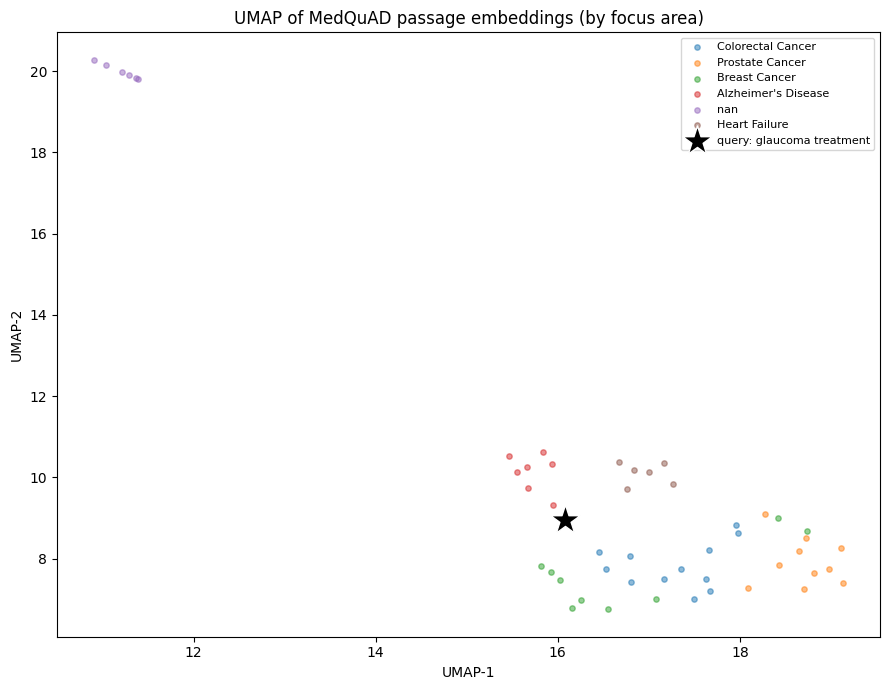

In [18]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import umap
except ImportError as exc:
    raise ImportError("Install umap-learn (Section 1) before running this cell.") from exc

# Focus on the most common focus areas so the plot is readable.
import pandas as pd
focus_series = pd.Series(doc_focus)
top_focus = focus_series.value_counts().head(6).index.tolist()
mask = focus_series.isin(top_focus).to_numpy()

sub_emb = doc_embeddings[mask]
sub_focus = focus_series[mask].to_numpy()

# Add a query embedding to see where it falls.
query_text = "What are the treatments for glaucoma?"
q_emb = retriever.encode([query_text], convert_to_numpy=True, normalize_embeddings=True).astype("float32")

combined = np.vstack([sub_emb, q_emb])
reducer = umap.UMAP(n_components=2, random_state=SEED, metric="cosine")
coords = reducer.fit_transform(combined)

doc_coords = coords[:-1]
query_coord = coords[-1]

plt.figure(figsize=(9, 7))
cmap = plt.get_cmap("tab10")
for j, focus in enumerate(top_focus):
    m = sub_focus == focus
    plt.scatter(doc_coords[m, 0], doc_coords[m, 1], s=15, alpha=0.5,
                color=cmap(j), label=str(focus)[:30])

plt.scatter(query_coord[0], query_coord[1], marker="*", s=500,
            color="black", edgecolors="white", linewidths=1.0,
            zorder=5, label="query: glaucoma treatment")

plt.title("UMAP of MedQuAD passage embeddings (by focus area)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()


---
## Section 13. Save the Retrieval Index

Persist the FAISS index and the passage metadata so the knowledge base can be reloaded without
re-encoding every passage.

In [19]:
from pathlib import Path
import json
import faiss

SAVE_DIR = Path("medquad_rag_index")
SAVE_DIR.mkdir(exist_ok=True)

faiss.write_index(index, str(SAVE_DIR / "passages.faiss"))

with open(SAVE_DIR / "passages.json", "w") as f:
    json.dump(
        {"documents": documents, "titles": doc_titles, "focus": doc_focus,
         "retriever": RETRIEVER_NAME, "generator": GENERATOR_NAME},
        f,
    )

print(f"Saved FAISS index and metadata to {SAVE_DIR.resolve()}")
print("Reload with: faiss.read_index('medquad_rag_index/passages.faiss')")


Saved FAISS index and metadata to /content/medquad_rag_index
Reload with: faiss.read_index('medquad_rag_index/passages.faiss')


---
## Section 14. Discussion Points for Journal Club

Use these questions to guide the group discussion:

1. **Parametric vs. non-parametric memory** — Lewis et al. argue that storing knowledge in a retrievable
   index (rather than model weights) makes knowledge *updatable* without retraining. How would you add a
   new medical guideline to this system? What breaks if you only had the closed-book model?

2. **Retriever quality is the ceiling** — In Section 11, how did recall@k change with k? If the correct
   passage is never retrieved, can the generator ever recover? How does this shape where you should invest
   effort?

3. **RAG-Sequence vs. RAG-Token** — The paper marginalises over retrieved documents in two ways. Our demo
   uses a simpler "stuff top-k into the prompt" approach. What are the trade-offs versus the paper's
   probabilistic marginalisation?

4. **Hallucination and grounding** — Compare the closed-book and RAG answers in Section 10. Did retrieval
   reduce unsupported claims? How would you *measure* faithfulness of the answer to the retrieved passages?

5. **Domain retriever** — We used a general `all-MiniLM-L6-v2` encoder. How might a biomedical retriever
   (e.g. one trained on PubMed) change retrieval quality on MedQuAD?

6. **Clinical safety** — MedQuAD comes from vetted NIH sources, but the generator can still rephrase
   incorrectly. What guardrails (citation display, abstention, human review) would you require before any
   clinical use?
